**Aula 04 — Redes Neurais Artificiais (MLP) + Dataset Iris**

**Disciplina:** Inteligência Artificial  
**Professor:** Marcelo Batista

🎯 **OBJETIVOS**

1. Entender a evolução do neurônio único (Perceptron) para Múltiplas Camadas (MLP).
2. Compreender a importância do pré-processamento (Escalonamento/Padronização) para Redes Neurais.
3. Treinar uma Rede Neural (`MLPClassifier`) para classificar as flores do dataset Iris.
4. Avaliar o modelo e fazer previsões em novos dados.
Na Aula 03, vimos que um único neurônio (Perceptron) consegue aprender regras simples. Porém, para problemas mais complexos, um neurônio não basta.

Uma **Rede Neural Artificial (Multi-Layer Perceptron - MLP)** conecta vários neurônios em camadas:
* **Camada de Entrada (Input):** Recebe os dados (no Iris, são 4 neurônios, um para cada medida da flor).
* **Camadas Ocultas (Hidden):** Onde a "mágica" acontece. Vários neurônios extraindo padrões complexos.
* **Camada de Saída (Output):** A decisão final (no Iris, 3 neurônios, um para cada espécie).

Vamos começar preparando nosso ambiente e carregando os dados, exatamente como fizemos na Aula 01.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. Carregar os dados
df = sns.load_dataset("iris")

# 2. Separar X (features) e y (target)
X = df.drop("species", axis=1)
y = df["species"]

# 3. Dividir em Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Dados separados! Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

✅ Dados separados! Treino: 120 amostras | Teste: 30 amostras


**⚠️ O Segredo das Redes Neurais: Escalonamento**

Diferente da Árvore de Decisão (Aula 01), as Redes Neurais são **muito sensíveis à escala dos dados**. Se uma variável vai de 0 a 1 e outra de 0 a 1000, os pesos da rede ficam confusos e o aprendizado falha.

Precisamos colocar todas as medidas na mesma escala usando o `StandardScaler` (que deixa a média em 0 e o desvio padrão em 1).

**Regra de Ouro:** Fazemos o `fit` (aprender a média) apenas no Treino, para não vazar informações do Teste!

In [ ]:
# Criar o padronizador
scaler = StandardScaler()

# FIT (aprender a média/desvio) e TRANSFORM (aplicar) no Treino
X_train_scaled = scaler.fit_transform(X_train)

# Apenas TRANSFORM no Teste (usando o que aprendeu no treino)
X_test_scaled = scaler.transform(X_test)

print("📊 Dados originais (primeira linha):", X_train.iloc[0].values)
print("⚖️ Dados escalonados (primeira linha):", np.round(X_train_scaled[0], 2))

📊 Dados originais (primeira linha): [4.6 3.6 1.  0.2]
⚖️ Dados escalonados (primeira linha): [-1.47  1.2  -1.56 -1.31]


**🚀 Treinando a Rede Neural (MLP)**

Agora vamos criar nossa Rede Neural usando o `MLPClassifier` do Scikit-Learn.
Vamos configurar duas camadas ocultas com 10 neurônios cada (`hidden_layer_sizes=(10, 10)`).

In [ ]:
# Criar a Rede Neural
# max_iter=1000 -> Número máximo de épocas (repetições) para o treino
modelo_rn = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    max_iter=1000,
    random_state=42
)

# Treinar o modelo (Aprender os pesos e bias)
print("🧠 Treinando a Rede Neural...")
modelo_rn.fit(X_train_scaled, y_train)
print("✅ Treino concluído!")

# Fazer previsões no conjunto de teste
predicoes = modelo_rn.predict(X_test_scaled)

# Medir a acurácia
acc = accuracy_score(y_test, predicoes)
print(f"\n🎯 Acurácia da Rede Neural: {acc * 100:.2f}%")

🧠 Treinando a Rede Neural...
✅ Treino concluído!

🎯 Acurácia da Rede Neural: 96.67%


🎨 Gerando o desenho da Rede Neural...


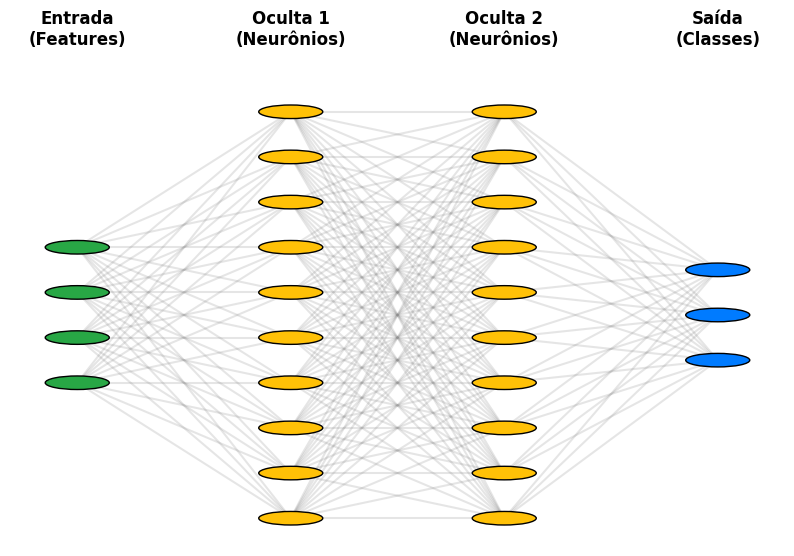

In [ ]:
import matplotlib.pyplot as plt

def visualizar_mlp(modelo, X):
    """
    Lê a arquitetura do modelo MLPClassifier treinado e desenha a rede neural.
    """
    # Descobrindo o tamanho de cada camada dinamicamente
    qtd_entrada = X.shape[1]
    qtd_ocultas = list(modelo.hidden_layer_sizes)
    qtd_saida = modelo.n_outputs_

    # Lista com o número de neurônios por camada (Ex: [4, 10, 10, 3])
    camadas = [qtd_entrada] + qtd_ocultas + [qtd_saida]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off') # Remove os eixos do gráfico

    tamanho_max = max(camadas)

    for i, num_neuronios in enumerate(camadas):
        x = i # Posição horizontal da camada
        y_inicio = (tamanho_max - num_neuronios) / 2 # Centralizar verticalmente

        # Nomear as camadas no topo
        if i == 0:
            titulo = "Entrada\n(Features)"
            cor = '#28a745' # Verde
        elif i == len(camadas) - 1:
            titulo = "Saída\n(Classes)"
            cor = '#007bff' # Azul
        else:
            titulo = f"Oculta {i}\n(Neurônios)"
            cor = '#ffc107' # Amarelo

        ax.text(x, tamanho_max + 0.5, titulo, ha='center', fontsize=12, fontweight='bold')

        # Desenhar os neurônios e as conexões
        for j in range(num_neuronios):
            y = y_inicio + j

            # Desenhar o neurônio (círculo)
            circulo = plt.Circle((x, y), 0.15, color=cor, ec='black', zorder=4)
            ax.add_patch(circulo)

            # Desenhar as linhas (pesos) conectando à próxima camada
            if i < len(camadas) - 1:
                num_neuronios_proxima = camadas[i+1]
                y_inicio_proxima = (tamanho_max - num_neuronios_proxima) / 2
                for k in range(num_neuronios_proxima):
                    y_proxima = y_inicio_proxima + k
                    # Linha cinza clara representando a conexão
                    ax.plot([x, x+1], [y, y_proxima], color='gray', alpha=0.2, zorder=1)

    plt.show()

# Chamando a função para desenhar a nossa rede treinada!
print("🎨 Gerando o desenho da Rede Neural...")
visualizar_mlp(modelo_rn, X_train_scaled)

**🔮 Teste "Mundo Real"**

Vamos simular a chegada de uma flor desconhecida no laboratório.
**Atenção:** a nova flor também precisa passar pelo `scaler` antes de entrar na rede!

In [ ]:
# Medidas de uma nova flor encontrada na natureza
nova_flor = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

# Escalonar o dado novo com o mesmo scaler do treino
nova_flor_scaled = scaler.transform(nova_flor)

# Fazer a previsão
previsao = modelo_rn.predict(nova_flor_scaled)
print(f"🌸 A Rede Neural classificou a nova flor como: {previsao[0].upper()}")

🌸 A Rede Neural classificou a nova flor como: SETOSA


🧪 **Exercício — Brincando com a Arquitetura da Rede**

**Objetivo:** Entender como o tamanho da rede e o tempo de treino afetam o aprendizado.

**Faça (crie novas células de código abaixo):**
1. Crie um novo modelo alterando o `hidden_layer_sizes` para `(3,)` (apenas uma camada com 3 neurônios). A acurácia cai?
2. Crie outro modelo alterando o `max_iter` para `20` (poucas épocas). O que acontece com o modelo se ele treinar por pouco tempo? (Dica: observe os avisos vermelhos de convergência).

Resolução do Exercício: Brincando com a Arquitetura

Neste exercício, vamos testar os limites da nossa Rede Neural alterando dois hiperparâmetros fundamentais: o tamanho do "cérebro" da rede (neurônios) e o tempo de estudo (épocas).



Resposta: Reduzindo o tamanho da rede para `(3,)`
O parâmetro `hidden_layer_sizes` define a quantidade de camadas ocultas e quantos neurônios existem em cada uma.
Na rede original, usamos `(10, 10)` (duas camadas com 10 neurônios). Agora, vamos usar `(3,)`, o que significa **apenas uma camada oculta contendo 3 neurônios**.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. Criando uma rede "menor" (1 camada oculta com 3 neurônios)
modelo_rn_pequeno = MLPClassifier(
    hidden_layer_sizes=(3,),
    max_iter=1000,
    random_state=42
)

# 2. Treinando o modelo com os dados escalonados
print("🧠 Treinando a rede pequena (3 neurônios)...")
modelo_rn_pequeno.fit(X_train_scaled, y_train)

# 3. Fazendo previsões e medindo a acurácia
predicoes_pequeno = modelo_rn_pequeno.predict(X_test_scaled)
acc_pequeno = accuracy_score(y_test, predicoes_pequeno)

print(f"🎯 Acurácia da Rede (3 neurônios): {acc_pequeno * 100:.2f}%")

🧠 Treinando a rede pequena (3 neurônios)...
🎯 Acurácia da Rede (3 neurônios): 96.67%


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


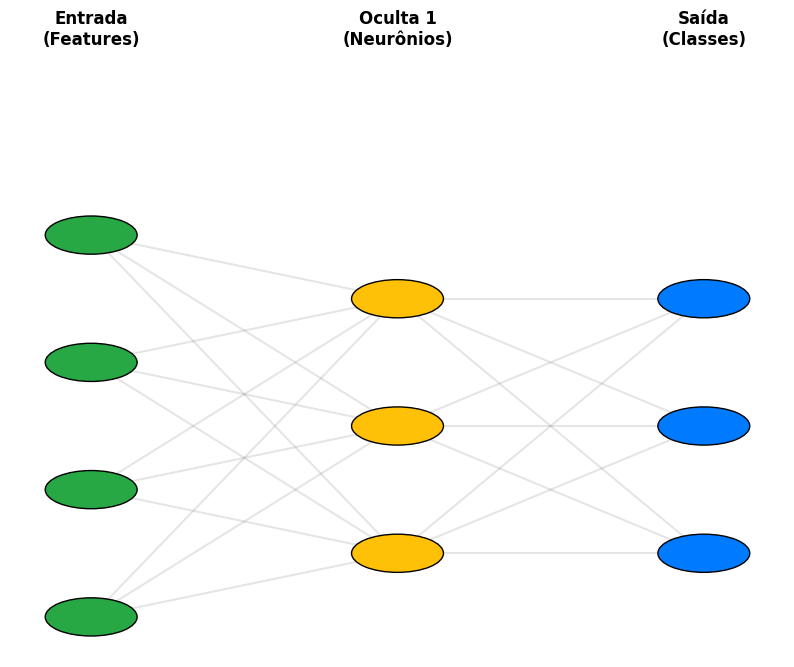

In [ ]:
visualizar_mlp(modelo_rn_pequeno, X_train_scaled)

**🧠 Por que isso acontece? (A Teoria)**

* **Capacidade de Aprendizado:** O número de neurônios define a capacidade da rede de entender padrões complexos. Uma rede com apenas 3 neurônios tem poucas "conexões matemáticas" para desenhar as fronteiras de decisão entre as espécies de flores.
* **Underfitting:** Quando reduzimos muito a rede em problemas complexos do mundo real, causamos *underfitting* (o modelo fica simples demais para entender os dados e erra muito).
* **No caso do Iris:** Como o dataset Iris é muito simples, mesmo 3 neurônios conseguem uma acurácia alta, mas a rede fica no seu limite. Se fosse um problema de reconhecimento de imagens, a acurácia despencaria para quase zero.



Resposta: Reduzindo o tempo de treino para `max_iter=20`

O parâmetro `max_iter` define o número máximo de **épocas** (quantas vezes a rede vai ver os dados de treino para ajustar os pesos).
Lembra do "Analista do Banco" da Aula 03? Ele precisou de várias épocas para zerar os erros. Vamos ver o que acontece se dermos apenas 20 épocas para a rede aprender.

In [ ]:
# 1. Criando a rede com poucas iterações (épocas)
modelo_rn_rapido = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    max_iter=20, # <-- Apenas 20 épocas!
    random_state=42
)

# 2. Treinando o modelo (Atenção ao aviso vermelho que vai aparecer!)
print("⏳ Treinando por apenas 20 épocas...")
modelo_rn_rapido.fit(X_train_scaled, y_train)

# 3. Fazendo previsões e medindo a acurácia
predicoes_rapido = modelo_rn_rapido.predict(X_test_scaled)
acc_rapido = accuracy_score(y_test, predicoes_rapido)

print(f"\n🎯 Acurácia da Rede (20 épocas): {acc_rapido * 100:.2f}%")

⏳ Treinando por apenas 20 épocas...

🎯 Acurácia da Rede (20 épocas): 33.33%


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


**🧠 Por que isso acontece? (A Teoria)**

* **O Aviso Vermelho (ConvergenceWarning):** O Scikit-Learn gerou um alerta dizendo que o limite de iterações (20) foi atingido e a otimização não convergiu.
* **O que significa não convergir?** Significa que a rede parou de treinar **antes** de encontrar os melhores pesos. É como se você tirasse a prova do aluno antes do tempo acabar.
* **Queda na Acurácia:** Como os pesos (a importância de cada medida da flor) pararam de ser ajustados no meio do caminho, a rede passa a "chutar" mal. A acurácia cai drasticamente porque o modelo literalmente não teve tempo de aprender a regra que separa as flores.